<a href="https://colab.research.google.com/github/Solomon-Million/Machine-Learning-Applications-in-VLSI-Testing/blob/main/Parity_with_Pycaret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Function to calculate parity
def calculate_parity(bits):
    return sum(bits) % 2

# Generate all possible input combinations for 8 bits
num_bits = 8
combinations = np.array(np.meshgrid(*[[0, 1]] * num_bits)).T.reshape(-1, num_bits)

# Calculate parity for each combination
data = []
for comb in combinations:
    parity = calculate_parity(comb)
    data.append(list(comb) + [parity])

# Create DataFrame
columns = [f'D{i}' for i in range(num_bits)] + ['Parity']
df = pd.DataFrame(data, columns=columns)

# Save to CSV
csv_path = '8bit_parity_truth_table.csv'
df.to_csv(csv_path, index=False)

print(f"Truth table saved to {csv_path}")


Truth table saved to 8bit_parity_truth_table.csv


In [ ]:
!pip install pycaret


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 38.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 29.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 20.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 42.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5

In [ ]:
import pandas as pd
from pycaret.classification import *

# Load the dataset
df = pd.read_csv('8bit_parity_truth_table.csv')

# Display the first few rows of the dataframe
df.head()


,D0,D1,D2,D3,D4,D5,D6,D7,Parity
0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,0,1
3,1,1,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,1


In [ ]:
# Initialize setup
clf = setup(data=df, target='Parity',  html=False, preprocess=True)



                    Description             Value
0                    Session id              2726
1                        Target            Parity
2                   Target type            Binary
3           Original data shape          (256, 9)
4        Transformed data shape          (256, 9)
5   Transformed train set shape          (179, 9)
6    Transformed test set shape           (77, 9)
7              Numeric features                 8
8                    Preprocess              True
9               Imputation type            simple
10           Numeric imputation              mean
11       Categorical imputation              mode
12               Fold Generator   StratifiedKFold
13                  Fold Number                10
14                     CPU Jobs                -1
15                      Use GPU             False
16               Log Experiment             False
17              Experiment Name  clf-default-name
18                          USI              a219


In [ ]:
# Compare models
best_model = compare_models(exclude=['dummy'])

                                    Model  Accuracy     AUC  Recall   Prec.  \
ridge                    Ridge Classifier    0.4758  0.4307  0.4847  0.4815   
lda          Linear Discriminant Analysis    0.4758  0.4307  0.4847  0.4815   
nb                            Naive Bayes    0.4703  0.4123  0.4847  0.4837   
ada                  Ada Boost Classifier    0.4703  0.4258  0.4847  0.4779   
lr                    Logistic Regression    0.4647  0.4272  0.4625  0.4710   
svm                   SVM - Linear Kernel    0.4637  0.4288  0.6208  0.4183   
lightgbm  Light Gradient Boosting Machine    0.3183  0.2508  0.3375  0.3201   
qda       Quadratic Discriminant Analysis    0.3013  0.2468  0.2917  0.2881   
gbc          Gradient Boosting Classifier    0.2794  0.2218  0.3056  0.2787   
xgboost         Extreme Gradient Boosting    0.1676  0.1020  0.1583  0.1551   
dt               Decision Tree Classifier    0.1399  0.1396  0.1236  0.1189   
rf               Random Forest Classifier    0.0392 

In [ ]:
# Create and train the best model
model = create_model(best_model)


      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.5556  0.6173  1.0000  0.5294  0.6923  0.1111  0.2425
1       0.3889  0.4198  0.6667  0.4286  0.5217 -0.2222 -0.2673
2       0.5556  0.5617  0.6667  0.5455  0.6000  0.1111  0.1140
3       0.6667  0.6790  0.4444  0.8000  0.5714  0.3333  0.3721
4       0.5000  0.6420  0.4444  0.5000  0.4706  0.0000  0.0000
5       0.6111  0.6420  0.7778  0.5833  0.6667  0.2222  0.2357
6       0.5556  0.4506  0.8889  0.5333  0.6667  0.1111  0.1491
7       0.4444  0.5185  0.8889  0.4706  0.6154 -0.1111 -0.2425
8       0.5000  0.6235  0.1111  0.5000  0.1818  0.0000  0.0000
9       0.5882  0.6111  0.4444  0.6667  0.5333  0.1905  0.2031
Mean    0.5366  0.5765  0.6333  0.5557  0.5520  0.0746  0.0807
Std     0.0769  0.0826  0.2584  0.1018  0.1406  0.1549  0.1986


In [ ]:
# Evaluate the model
evaluate_model(model)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Predict on new data
predictions = predict_model(model, data=df)
predictions.head()


                 Model  Accuracy  AUC  Recall  Prec.      F1  Kappa  MCC
0  SVM - Linear Kernel       0.5  0.5  0.8906    0.5  0.6404    0.0  0.0


,D0,D1,D2,D3,D4,D5,D6,D7,Parity,prediction_label
0,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,0,1,1
2,1,0,0,0,0,0,0,0,1,0
3,1,1,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0,1,1


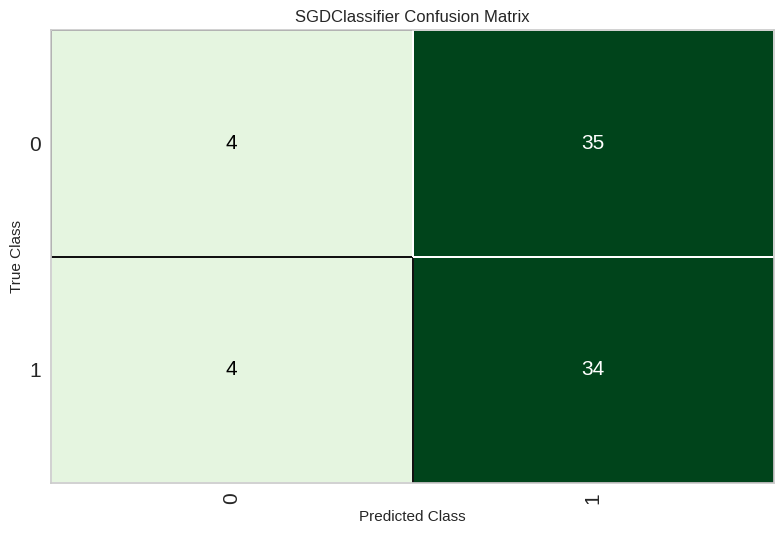

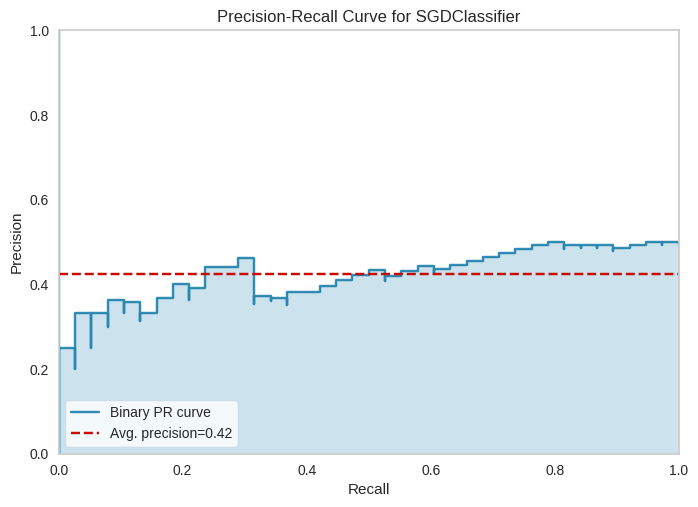

In [ ]:
# Display the model's metrics
plot_model(model, plot='confusion_matrix')
#plot_model(model, plot='auc')
plot_model(model, plot='pr')
#plot_model(model, plot='feature')
